<a href="https://colab.research.google.com/github/antoniovfonseca/agentic-ai-global-lulc/blob/main/notebooks/quest-gee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Environment Setup

First, we will install and import the necessary libraries to handle spatial data processing.

In [1]:
# Install dependency
!pip install geemap -q > /dev/null 2>&1
!apt-get install -y gdal-bin -q > /dev/null 2>&1
!pip install matplotlib-scalebar -q > /dev/null 2>&1

## 1.1 Global Configuration

Users **must** configure the following parameters to ensure the notebook executes correctly:

1.  **GEE User**: Your Google Earth Engine project ID or username.
2.  **Global Directory Paths**: The specific Google Drive folder name where GEE exports will be stored and read from.
3.  **Time Points**: The range or list of years to be processed for the analysis.
4.  **Spatial Resolution**: The resolution (in meters) for the Earth Engine exports.

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# 1. GEE User
user = 'antfonseca-499920'

# 2. Global Directory Paths
folder_name = "GLANCE_SA_300m_2001_to_2019"
base_drive_dir = f"/content/drive/MyDrive/{folder_name}"

# 3. Define the time points
years_to_process = list(range(2001, 2020))
#years_to_process = [2017, 2018]

# 4. Define the spatial resolution
spatial_resolution = 300


In [4]:
import ee

# Authenticate and initialize Earth Engine using the global 'user' variable
try:
    ee.Initialize(project=user)
    print(f"Earth Engine initialized successfully for project: {user}")
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=user)
    print(f"Earth Engine authenticated and initialized for project: {user}")


Earth Engine initialized successfully for project: antfonseca-499920


## 1.2 Import libraries and GitHub repository

In [5]:
# Import libraries
import pandas as pd
import os
import sys
import geemap

# Define repository details
repo_url = 'https://github.com/antoniovfonseca/agentic-ai-global-lulc.git'
repo_name = 'agentic-ai-global-lulc'

# Clone or update the repository
if not os.path.exists(repo_name):
    print(f"Cloning {repo_name}...")
    !git clone {repo_url}
else:
    print(f"Updating {repo_name}...")
    !cd {repo_name} && git pull

# Add the notebooks directory to system path to allow imports
notebooks_path = os.path.join(repo_name, 'notebooks')
if notebooks_path not in sys.path:
    sys.path.append(os.path.abspath(notebooks_path))
    print(f"Added {notebooks_path} to system path.")

import importlib
import utils

importlib.reload(utils)
print("Utils module loaded successfully.")

Updating agentic-ai-global-lulc...
Already up to date.
Added agentic-ai-global-lulc/notebooks to system path.
Utils module loaded successfully.


# 2.GLanCE Visualization

In [ ]:
# Visualize GLanCE data from GEE
target_year = 2019

glance_map = utils.get_glance_map(target_year)

if glance_map:
    display(glance_map)

# 3.Class Area at Time Points

## 3.1 Compute Class Area for each time point

In [9]:
# Submit pixel count export tasks to GEE
print("Starting global pixel count exports via GEE...")

tasks_counts = utils.export_global_pixel_counts_tasks(
    year_list=years_to_process,
    drive_folder=folder_name,
    scale=spatial_resolution
)

print(f"\nSuccess! {len(tasks_counts)} tasks have been submitted to GEE.")

Starting global pixel count exports via GEE...
Task submitted for year 2016.

Success! 1 tasks have been submitted to GEE.


## 3.2 Plot Class area

Generating the bar graphic from Drive CSVs...
Chart successfully saved at: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/chart_pixel_per_class_net_change.png


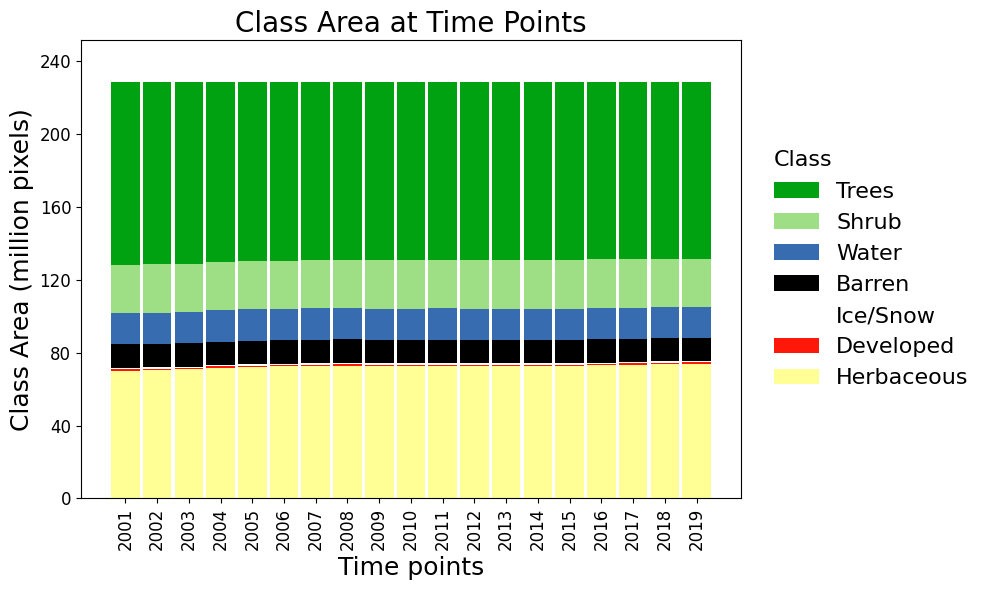

In [20]:
# Plot pixel counts bar chart from Drive CSVs
print("Generating the bar graphic from Drive CSVs...")

utils.plot_pixel_counts_bar_chart(
    input_dir=base_drive_dir,
    class_labels_dict=utils.GLANCE_METADATA,
    output_dir=base_drive_dir
)

# 4.Number of Changes

## 4.1 Compute Number of Changes raster map

In [ ]:
# Submit number of changes raster export task to GEE
importlib.reload(utils)

print("Submitting Number of Changes Raster Task to GEE...")

num_changes_raster_task = utils.export_global_number_of_changes_raster_task(
    year_list=years_to_process,
    drive_folder=folder_name,
    scale=spatial_resolution
)

print("\nSuccess! Raster export task submitted to GEE.")

## 4.2 Compute Number of Changes during time intervals

In [33]:
# Submit global number of changes tasks to GEE
print("Submitting Number of Changes Tasks to GEE...")

change_freq_tasks = utils.export_global_change_frequency_tasks(
    year_list=years_to_process,
    drive_folder=folder_name,
    scale=spatial_resolution
)

print(f"\nSuccess! {len(change_freq_tasks)} tasks submitted to GEE.")

Submitting Number of Changes Tasks to GEE...
Task submitted for interval 2017-2018

Success! 1 tasks submitted to GEE.


## 4.3 Plot Number of Changes during time intervals

Generating the number of changes graphic from Drive CSVs...


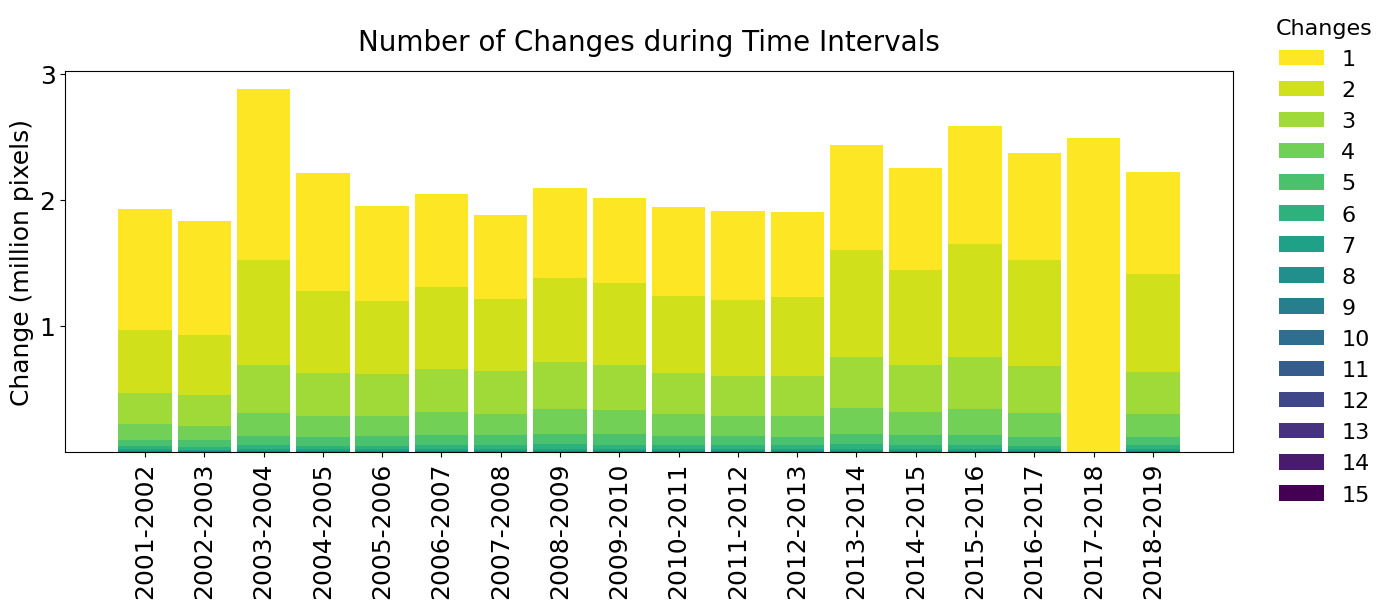

Chart saved to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/chart_number_change_time_interval.png


In [35]:
# Plot global number of changes during time intervals from Drive CSVs
print("Generating the number of changes graphic from Drive CSVs...")

utils.plot_global_change_frequency_bar_chart(
    input_dir=base_drive_dir,
    output_dir=base_drive_dir
)

## 4.4 Plot Number of Changes overall

Generating the number of changes overall graphic from Drive CSVs...
Loading overall change frequency directly from raster: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/Number_of_Changes_Raster_2001_2019.tif


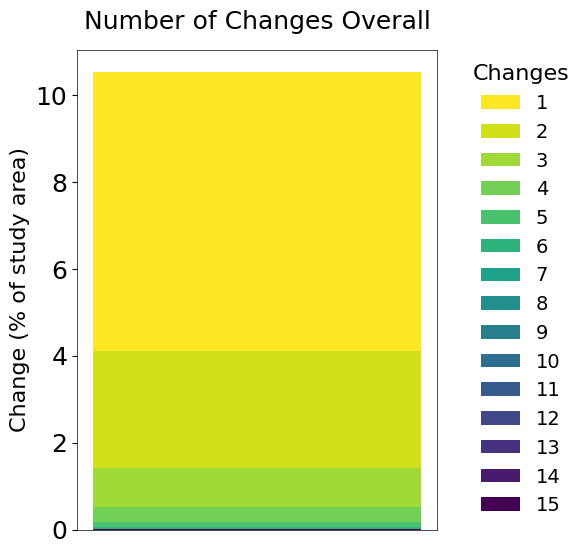

Chart saved to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/chart_number_changes_percentage_overall.png


In [36]:
# Plot number of changes overall from Drive CSVs
print("Generating the number of changes overall graphic from Drive CSVs...")

utils.plot_number_of_changes_distribution(
    input_dir=base_drive_dir,
    output_dir=base_drive_dir
)

## 4.5 Plot Number of Change map

Generating the global Number of Changes map from Drive rasters...


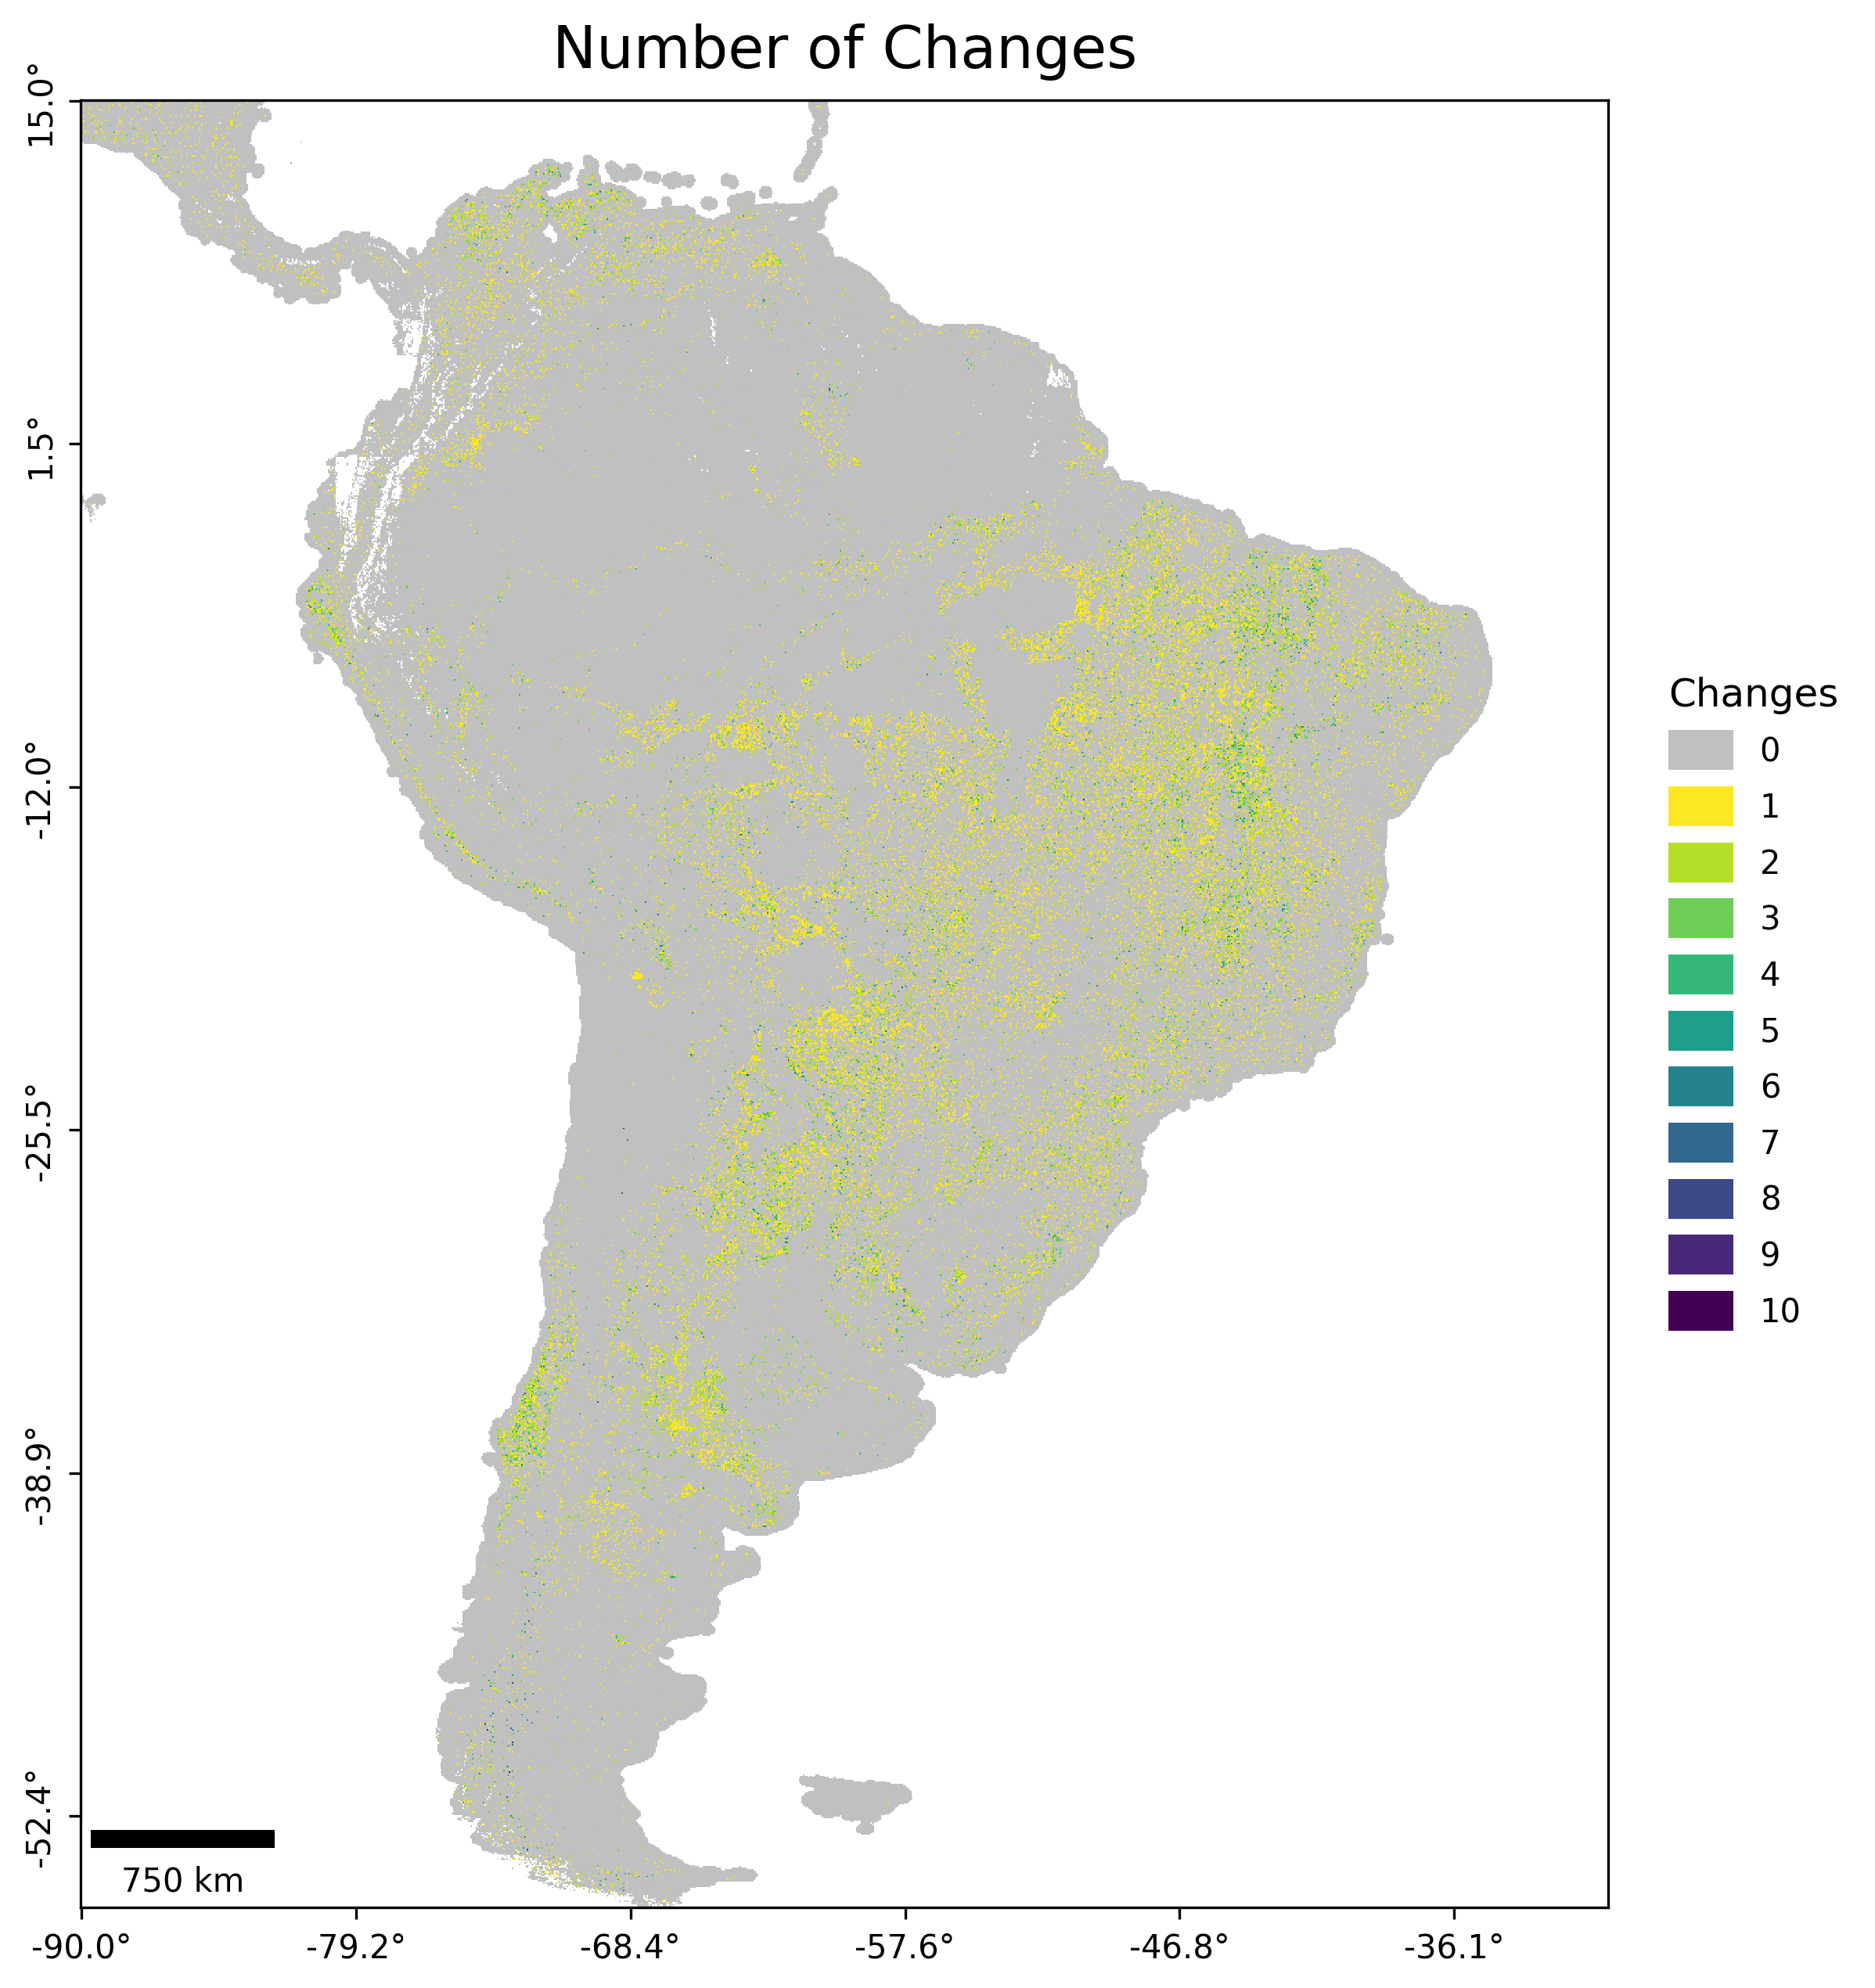

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/maps/map_number_of_changes.png


In [19]:
# Plot global number of changes map from Drive rasters
print("Generating the global Number of Changes map from Drive rasters...")

try:
    utils.plot_number_of_changes_map(
        output_dir=base_drive_dir,
        nodata_val=255,
        raster_filename="Number_of_Changes_Raster",
        scale_factor=0.05
    )
except Exception as e:
    print(f"\nError: {e}")

# 5.Trajectory Analysis

## 5.1 Compute Trajectory raster map

In [57]:
# Submit trajectory raster export task to GEE
importlib.reload(utils)

print("Submitting Trajectory Raster Task to GEE...")

trajectory_task = utils.export_trajectory_task_gee(
    year_list=years_to_process,
    drive_folder=folder_name,
    scale=spatial_resolution,
    collection_id=utils.GLANCE_COLLECTION_ID,
    band_name=utils.GLANCE_CLASS_BAND,
    nodata_val=utils.NODATA_VALUE
)

print("\nSuccess! Raster export task submitted to GEE.")

Submitting Trajectory Raster Task to GEE...
Task 'Trajectory_Analysis_2001_2019' submitted to Google Earth Engine.

Success! Raster export task submitted to GEE.


## 5.2 Compute Trajectories during time intervals

In [29]:
# Submit trajectory intervals CSV export task to GEE
importlib.reload(utils)

print("Submitting Trajectory during time intervals CSV Task to GEE...")

trajectory_intervals_task = utils.export_trajectory_intervals_csv_gee(
    year_list=years_to_process,
    drive_folder=folder_name,
    scale=spatial_resolution
)

print("\nSuccess! CSV export task submitted to GEE.")

Submitting Trajectory during time intervals CSV Task to GEE...
Preparing Trajectory Contributions GEE Task for 2001-2019...
Task 'Trajectory_Contributions_2001_2019' submitted to Google Earth Engine.

Success! CSV export task submitted to GEE.


## 5.3 Compute Trajectory overall

In [28]:
# Submit trajectory overall CSV export task to GEE
importlib.reload(utils)

print("Submitting Trajectory overall CSV Task to GEE...")

trajectory_overall_task = utils.export_trajectory_overall_csv_gee(
    year_list=years_to_process,
    drive_folder=folder_name,
    scale=spatial_resolution
)

print("\nSuccess! CSV export task submitted to GEE.")

Submitting Trajectory overall CSV Task to GEE...
Task 'Trajectory_Overall_2001_2019' submitted to Google Earth Engine.

Success! CSV export task submitted to GEE.


## 5.4 Plot Trajectory per time intervals

Loading data from: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/Trajectory_Contributions_2001_2019.csv


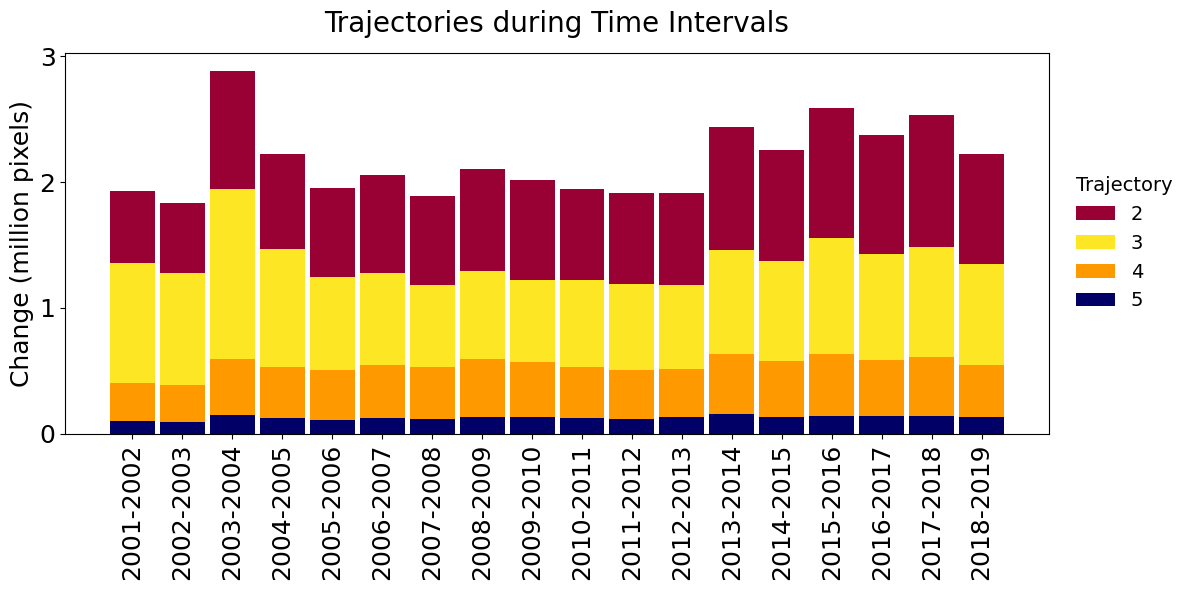

Figure saved to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/graphic_trajectory_time_interval.png


In [30]:
# Plot trajectories per time interval from Drive CSVs
importlib.reload(utils)

csv_filename = f"Trajectory_Contributions_{years_to_process[0]}_{years_to_process[-1]}.csv"
csv_path = os.path.join(base_drive_dir, csv_filename)

print(f"Loading data from: {csv_path}")

try:
    df_trajectory_intervals = pd.read_csv(
        csv_path,
        index_col="Interval"
    )

    # Filter relevant trajectory columns
    valid_cols = [col for col in df_trajectory_intervals.columns if col in ['2', '3', '4', '5']]
    df_trajectory_intervals = df_trajectory_intervals[valid_cols]

    utils.plot_trajectory_contributions(
        df=df_trajectory_intervals,
        output_path=base_drive_dir
    )
except FileNotFoundError:
    print(f"Error: File {csv_filename} not found. Ensure the GEE task is finished.")

## 5.5 Plot Trajectory overall

Reading total area from: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/Pixel_Counts_LULC_2001.csv
-> Total valid pixels: 228,637,895

Generating the overall trajectory graphic from Drive CSVs...


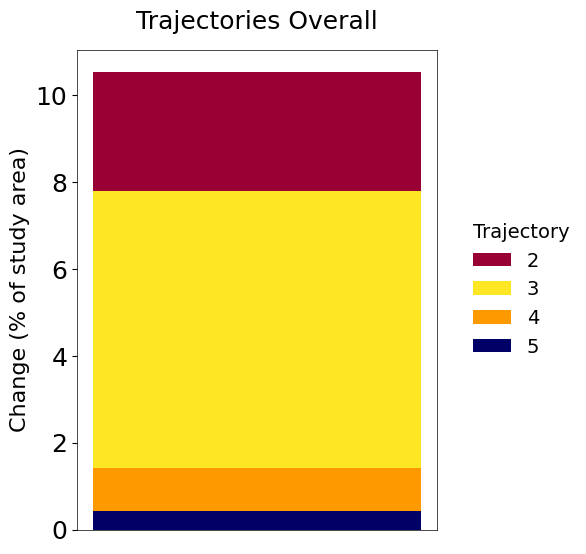

Figure saved to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/graphic_trajectory_percentage_overall.png


In [31]:
# Plot trajectories overall from Drive CSVs
importlib.reload(utils)

y_start, y_end = years_to_process[0], years_to_process[-1]
lulc_csv_path = os.path.join(base_drive_dir, f"Pixel_Counts_LULC_{y_start}.csv")

total_valid_pixels = 0
if os.path.exists(lulc_csv_path):
    print(f"Reading total area from: {lulc_csv_path}")
    df_lulc = pd.read_csv(lulc_csv_path)

    cols_to_ignore = ['system:index', '.geo', 'Period', '255']
    valid_cols = [c for c in df_lulc.columns if c not in cols_to_ignore]

    total_valid_pixels = df_lulc[valid_cols].sum().sum()
    print(f"-> Total valid pixels: {total_valid_pixels:,.0f}")

overall_csv_filename = f"Trajectory_Overall_{y_start}_{y_end}.csv"

if total_valid_pixels > 0:
    print("\nGenerating the overall trajectory graphic from Drive CSVs...")
    utils.plot_trajectory_distribution(
        input_dir=base_drive_dir,
        csv_filename=overall_csv_filename,
        total_pixels=total_valid_pixels
    )

## 5.5 Plot Trajectory map

Generating the global Trajectory map from Drive rasters...


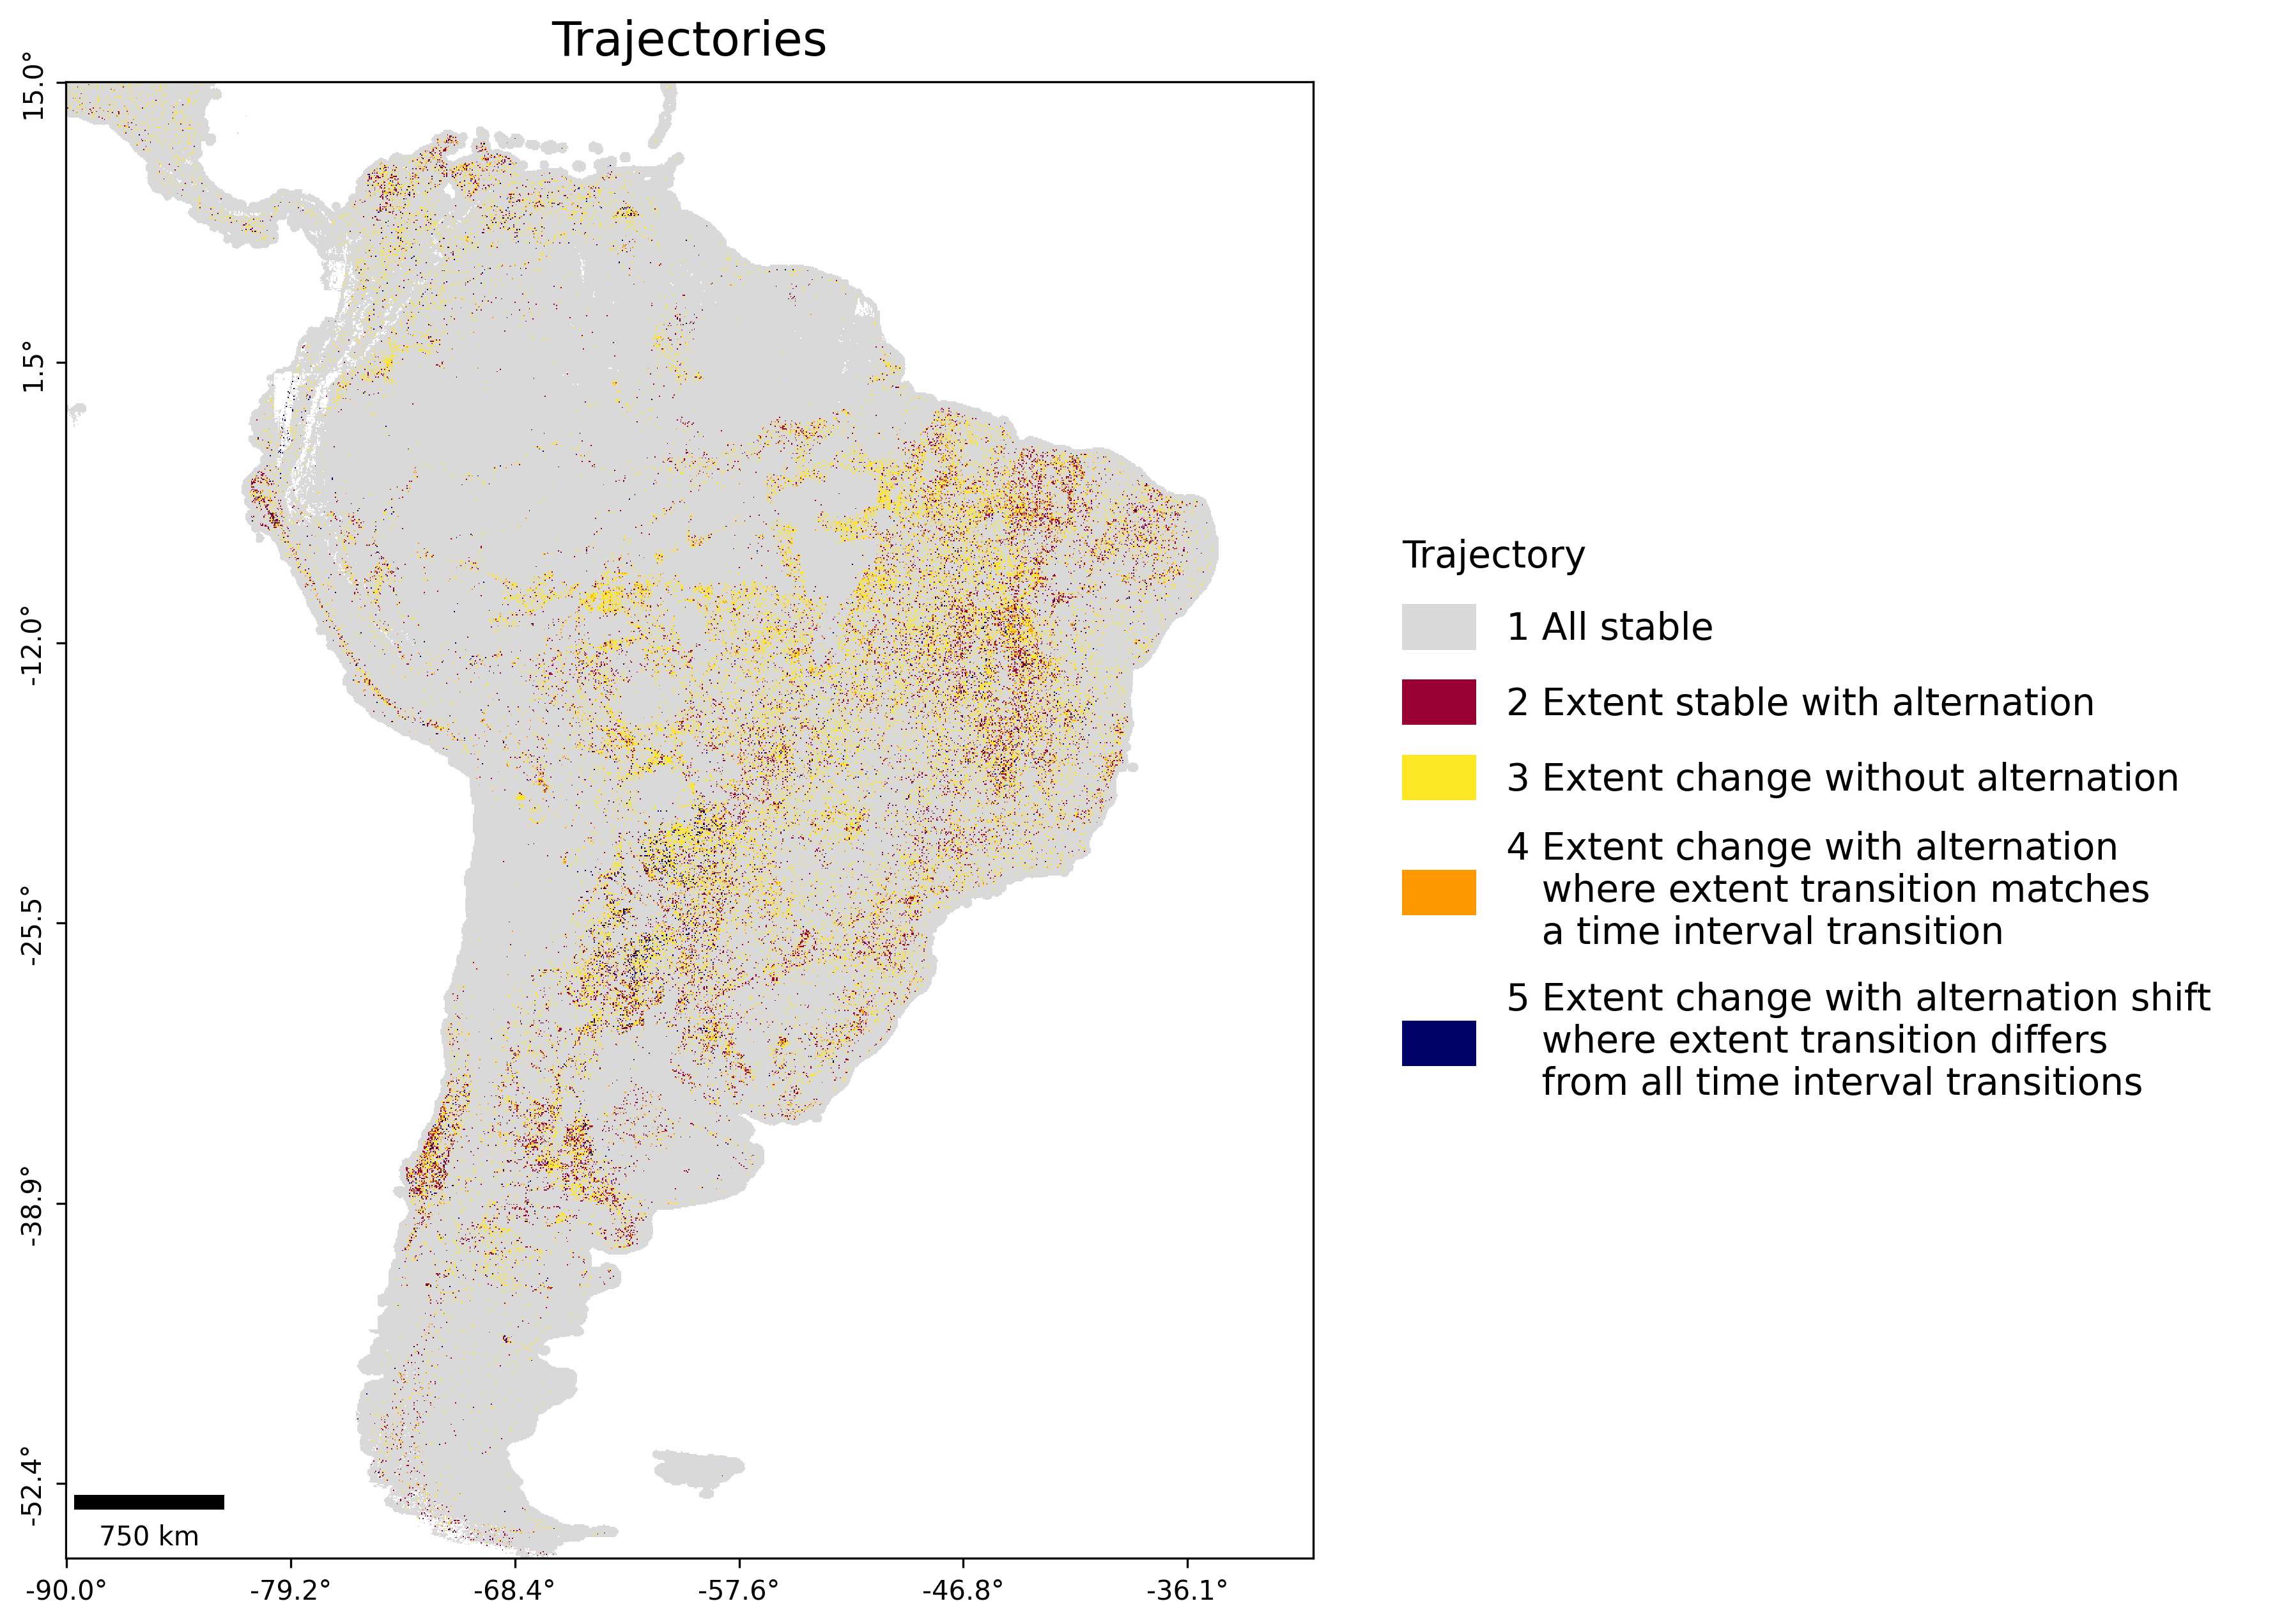

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/maps/map_trajectories.png


In [58]:
# Plot trajectory map from Drive rasters
importlib.reload(utils)

print("Generating the global Trajectory map from Drive rasters...")
utils.plot_trajectory_map(
    output_dir=base_drive_dir,
    raster_filename="Trajectory_Analysis",
    scale_factor=0.05,
    nodata_val=255
)

# 6.QUEST Analysis

## 6.1 Compute Transition matrix

In [37]:
# Submit interval transition tasks to GEE
importlib.reload(utils)

print("Submitting interval transition matrix tasks to GEE...")

# Save CSV results in the project directory
transition_tasks = utils.export_global_transition_tasks(
    year_list=years_to_process,
    drive_folder=folder_name,
    scale=spatial_resolution
)

print(f"\nSuccess! Submitted {len(transition_tasks)} tasks to GEE.")

Submitting interval transition matrix tasks to GEE...
Task started for transition_2001_2002 (Scale: 300m)
Task started for transition_2002_2003 (Scale: 300m)
Task started for transition_2003_2004 (Scale: 300m)
Task started for transition_2004_2005 (Scale: 300m)
Task started for transition_2005_2006 (Scale: 300m)
Task started for transition_2006_2007 (Scale: 300m)
Task started for transition_2007_2008 (Scale: 300m)
Task started for transition_2008_2009 (Scale: 300m)
Task started for transition_2009_2010 (Scale: 300m)
Task started for transition_2010_2011 (Scale: 300m)
Task started for transition_2011_2012 (Scale: 300m)
Task started for transition_2012_2013 (Scale: 300m)
Task started for transition_2013_2014 (Scale: 300m)
Task started for transition_2014_2015 (Scale: 300m)
Task started for transition_2015_2016 (Scale: 300m)
Task started for transition_2016_2017 (Scale: 300m)
Task started for transition_2017_2018 (Scale: 300m)
Task started for transition_2018_2019 (Scale: 300m)
Task start

## 6.2 Compute Aggregation matrices

In [38]:
# Submit unaccounted extent task to GEE
task_unaccounted = utils.export_unaccounted_extent_task_gee(
    year_list=years_to_process,
    drive_folder=folder_name,
    scale=spatial_resolution,
    nodata_val=utils.NODATA_VALUE
)

print(f"Success! Unaccounted Extent task submitted (ID: {task_unaccounted.id}).")

Preparing Unaccounted Extent GEE Task for 2001-2019...
Task 'Unaccounted_Extent_2001_2019' submitted to Google Earth Engine.
Success! Unaccounted Extent task submitted (ID: AWCWFZICIRPFNQQVS23DBD2R).


In [43]:
# Calculate aggregated components from Drive CSVs
importlib.reload(utils)

print("Calculating aggregated components from Drive CSVs...")

utils.calculate_aggregated_components_csv(
    year_list=years_to_process,
    input_dir=base_drive_dir,
    output_dir=base_drive_dir
)

print("\nReloading matrices...")
matrices = utils.load_and_reorder_matrices(
    output_path=base_drive_dir,
    year_list=years_to_process
)

print(f"\nSuccess! {len(matrices)} matrices loaded.")

Calculating aggregated components from Drive CSVs...
Computing Sum Matrix from GEE pixel transitions...
Loading Extent Matrix...
Saved sum matrix: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/transition_matrix_sum_2001-2019.csv
Saved extent matrix: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/transition_matrix_extent_2001-2019.csv
Saved allocation_exchange matrix: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/transition_matrix_allocation_exchange_2001-2019.csv
Saved quantity_allocation_shift matrix: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/transition_matrix_quantity_allocation_shift_2001-2019.csv
Saved alternation_exchange matrix: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/transition_matrix_alternation_exchange_2001-2019.csv
Saved alternation_shift matrix: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/transition_matrix_alternation_shift_2001-2019.csv

All aggregated component matrices successfully generated!

Reloading matrices...

Success! 7 mat

In [44]:
# 1. Compute SUM matrix from interval CSVs
df_sum = utils.compute_sum_matrix(
    input_dir=base_drive_dir,
    output_path=os.path.join(
        base_drive_dir,
        f"transition_matrix_sum_{years_to_process[0]}-{years_to_process[-1]}.csv"
    ),
    file_prefix="transition_"
)

# 2. Load Extent matrix
df_ext = utils.load_square_matrix(
    os.path.join(
        base_drive_dir,
        f"transition_{years_to_process[0]}_{years_to_process[-1]}.csv"
    )
)

# 3. Decompose and save standard components
utils.compute_and_save_components(
    df_sum=df_sum,
    df_ext=df_ext,
    output_dir=base_drive_dir,
    period_label=f"{years_to_process[0]}-{years_to_process[-1]}"
)

# 4. Reload and reorder all matrices
matrices = utils.load_and_reorder_matrices(
    output_path=base_drive_dir,
    year_list=years_to_process
)

SUM matrix successfully saved to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/transition_matrix_sum_2001-2019.csv
Component saved: transition_matrix_sum_2001-2019.csv
Component saved: transition_matrix_extent_2001-2019.csv
Component saved: transition_matrix_allocation_exchange_2001-2019.csv
Component saved: transition_matrix_allocation_shift_2001-2019.csv
Component saved: transition_matrix_alternation_exchange_2001-2019.csv
Component saved: transition_matrix_alternation_shift_2001-2019.csv


## 6.3 Compute Components of Change

In [45]:
# Generate change components summary table
importlib.reload(utils)

print("Generating change components summary table...")

utils.generate_change_components_table(
    year_list=years_to_process,
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
    class_labels_dict=utils.GLANCE_METADATA
)

Generating change components summary table...


Processing aggregated matrices: 100%|██████████| 4/4 [00:00<00:00, 243.59it/s]


Success! Final components saved to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/tables/change_components.csv


## 6.4 Plot Heat Maps

### 6.4.1 Input Setup and Interity Checks

In [46]:
# Validate and extract interval string
importlib.reload(utils)

try:
    interval_str = utils.validate_and_get_interval(
        years=years_to_process,
        output_path=base_drive_dir,
        class_labels_dict=utils.GLANCE_METADATA
    )
    print(f"Validation successful! Interval string: {interval_str}")
except ValueError as e:
    print(f"Validation Error: {e}")

Validation successful! Interval string: 2001-2019


### 6.4.2 Data Transformation and Matrix Alignment

In [47]:
# Load and reorder matrices
importlib.reload(utils)

try:
    matrices = utils.load_and_reorder_matrices(
        output_path=base_drive_dir,
        year_list=years_to_process
    )
    print(f"Success! {len(matrices)} matrices loaded.")
except Exception as e:
    print(f"Error loading matrices: {e}")

Success! 7 matrices loaded.


### 6.4.3 Plot heat maps

Generating Heatmaps...


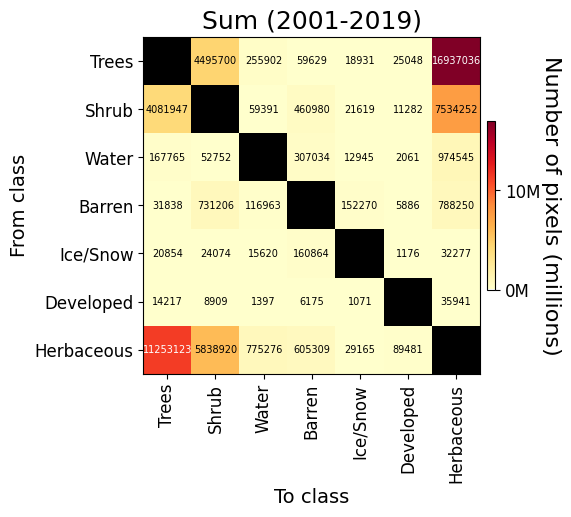

-> Saved heatmap: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/heatmap_sum_2001-2019.png


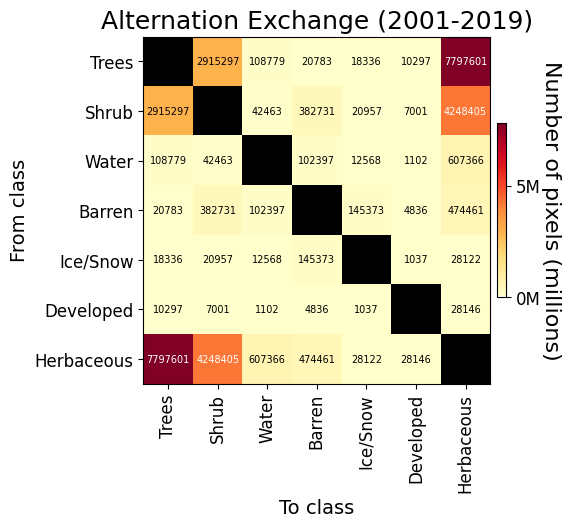

-> Saved heatmap: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/heatmap_alt_exc_2001-2019.png


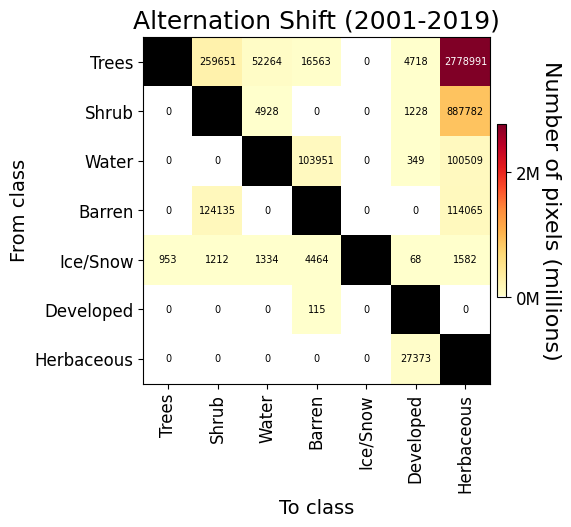

-> Saved heatmap: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/heatmap_alt_shift_2001-2019.png


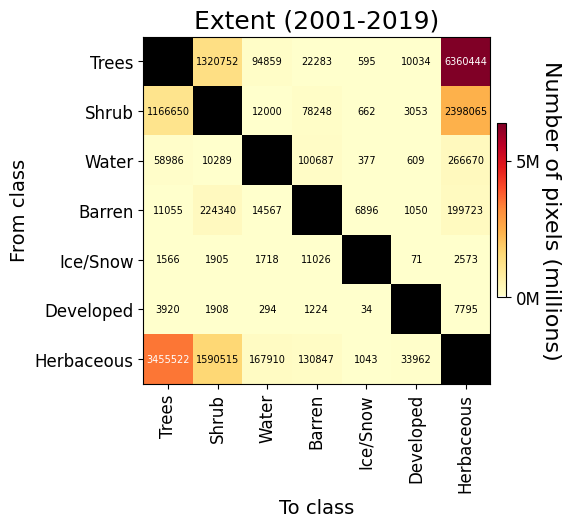

-> Saved heatmap: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/heatmap_ext_2001-2019.png


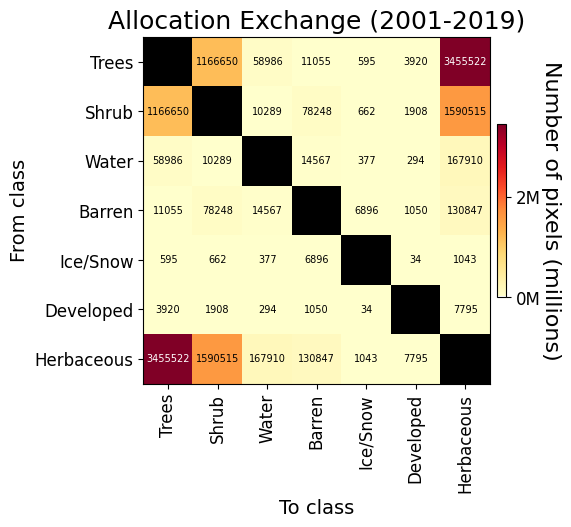

-> Saved heatmap: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/heatmap_all_exc_2001-2019.png


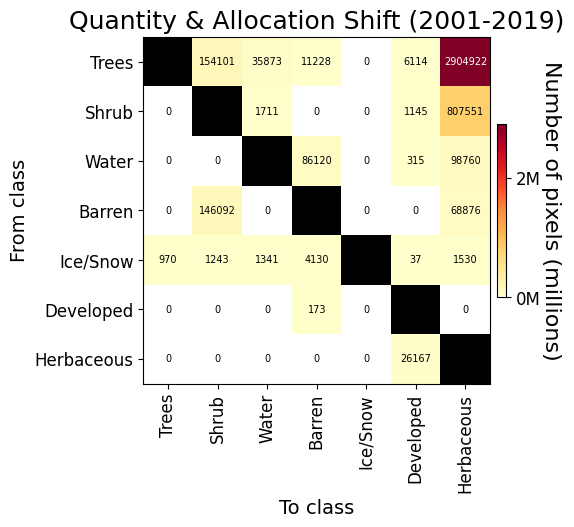

-> Saved heatmap: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/heatmap_qty_shift_2001-2019.png


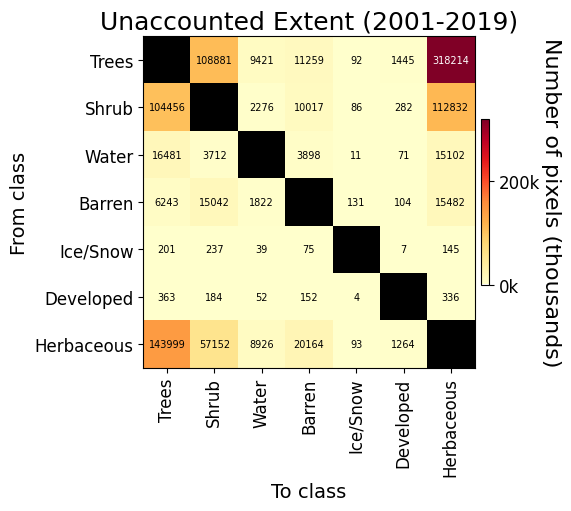

-> Saved heatmap: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/heatmap_unacc_ext_2001-2019.png


In [48]:
# Plot all heatmaps
importlib.reload(utils)

style_config = {
    "tick_fontsize_x": 12,
    "tick_fontsize_y": 12,
    "axis_label_fontsize": 14,
    "title_fontsize": 18,
    "ann_fontsize": 7,
    "cbar_fraction": 0.025,
    "cbar_pad": 0.02,
    "cbar_tick_labelsize": 12,
    "cbar_label_fontsize": 16,
    "cmap": "YlOrRd",
    "cell_size_inch": 0.8,
}

utils.generate_all_heatmaps(
    matrices_dict=matrices,
    output_path=base_drive_dir,
    interval_str=interval_str,
    years=years_to_process,
    style_config=style_config
)

## 6.5 Charts

### 6.5.1 Plot QUEST during time intervals

Generating change components during time intervals chart...


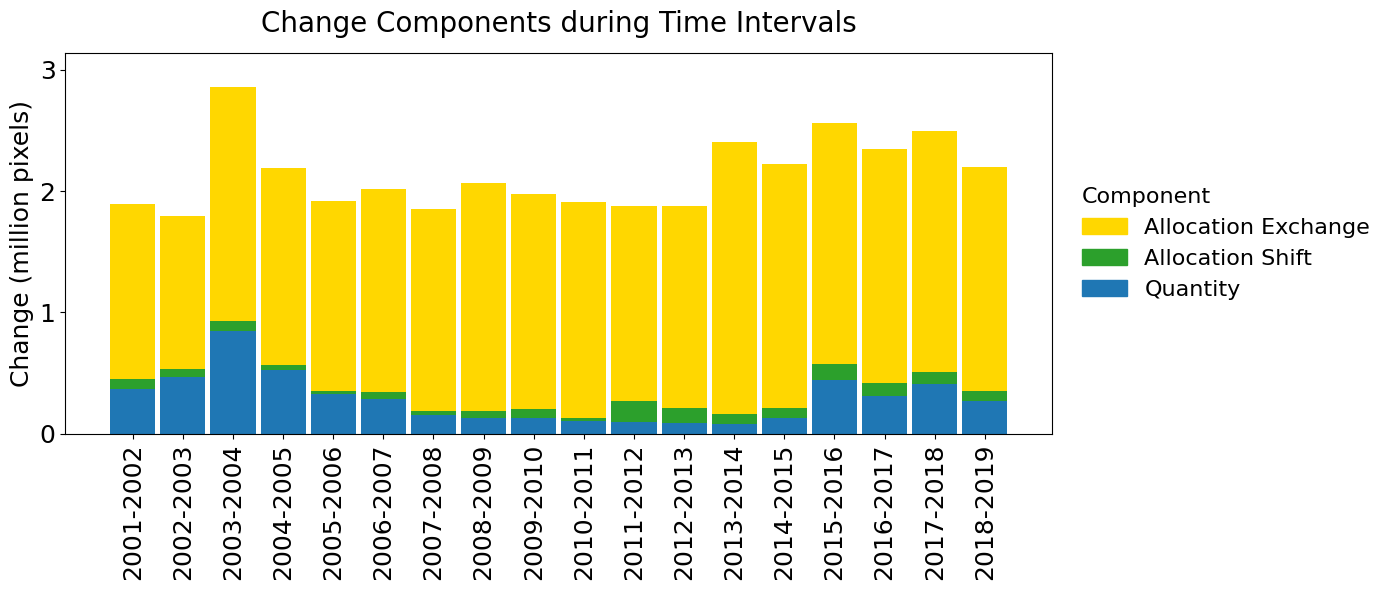

Chart saved to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/chart_change_components_time_interval.png


In [49]:
# Plot change components during time intervals
importlib.reload(utils)

print("Generating change components during time intervals chart...")

utils.plot_change_components_time_intervals(
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
)

### 6.5.2 Plot QUEST overall

Generating overall components of change graphic...


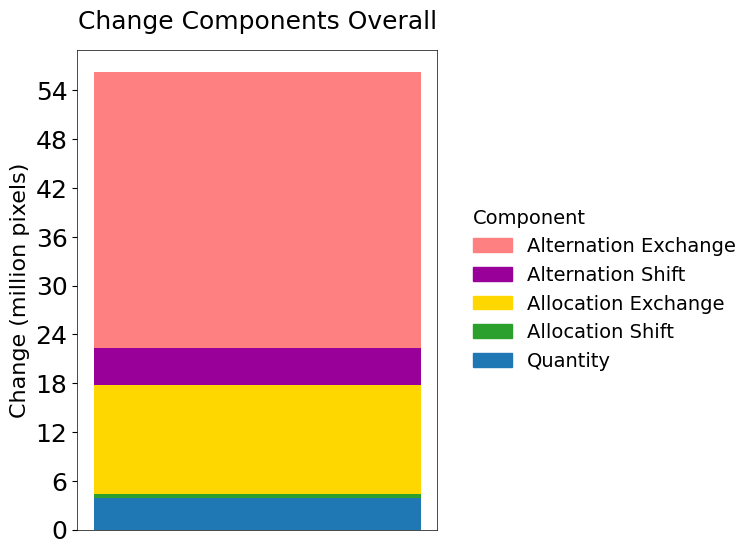

Chart saved to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/graphic_change_components_overall.png


In [50]:
# Plot overall change components
importlib.reload(utils)

print("Generating overall components of change graphic...")

csv_components_path = os.path.join(
    base_drive_dir,
    "tables",
    "change_components.csv",
)

utils.plot_components_with_alternation(
    csv_path=csv_components_path,
    output_path=base_drive_dir,
)

### 6.5.3 Plot QUEST by class

Generating change components by class graphic...


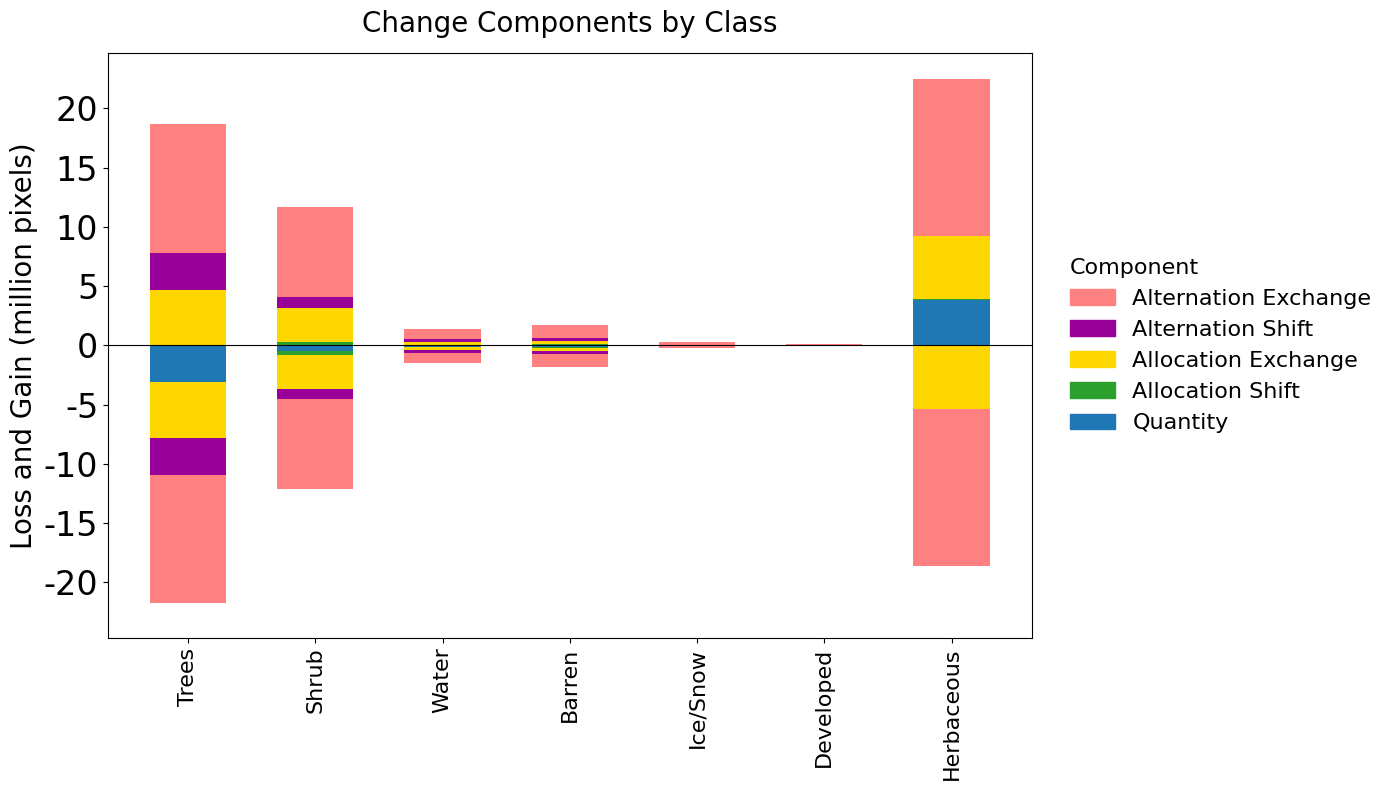

Chart saved to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/charts/chart_change_component_change_class.png


In [51]:
# Plot change components by class
importlib.reload(utils)

print("Generating change components by class graphic...")

utils.plot_change_components_by_class(
    input_dir=base_drive_dir,
    output_dir=base_drive_dir,
    class_labels_dict=utils.GLANCE_METADATA
)

## 6.6 Maps

### 6.6.1 Compute Extent raster map

In [16]:
# Submit quantity component raster task to GEE
importlib.reload(utils)

print("Submitting Quantity Component Raster Task to GEE...")

quantity_raster_task = utils.export_quantity_component_task_gee(
    year_list=years_to_process,
    drive_folder=folder_name,
    scale=spatial_resolution,
    nodata_val=utils.NODATA_VALUE,
)

print("\nSuccess! Task submitted to GEE.")

Submitting Quantity Component Raster Task to GEE...
Task 'Quantity_Component_2001_2019' submitted to Google Earth Engine with NoData: 255

Success! Task submitted to GEE.


### 6.6.2 Plot Extent change map

Generating the global Extent Change map from Drive rasters...


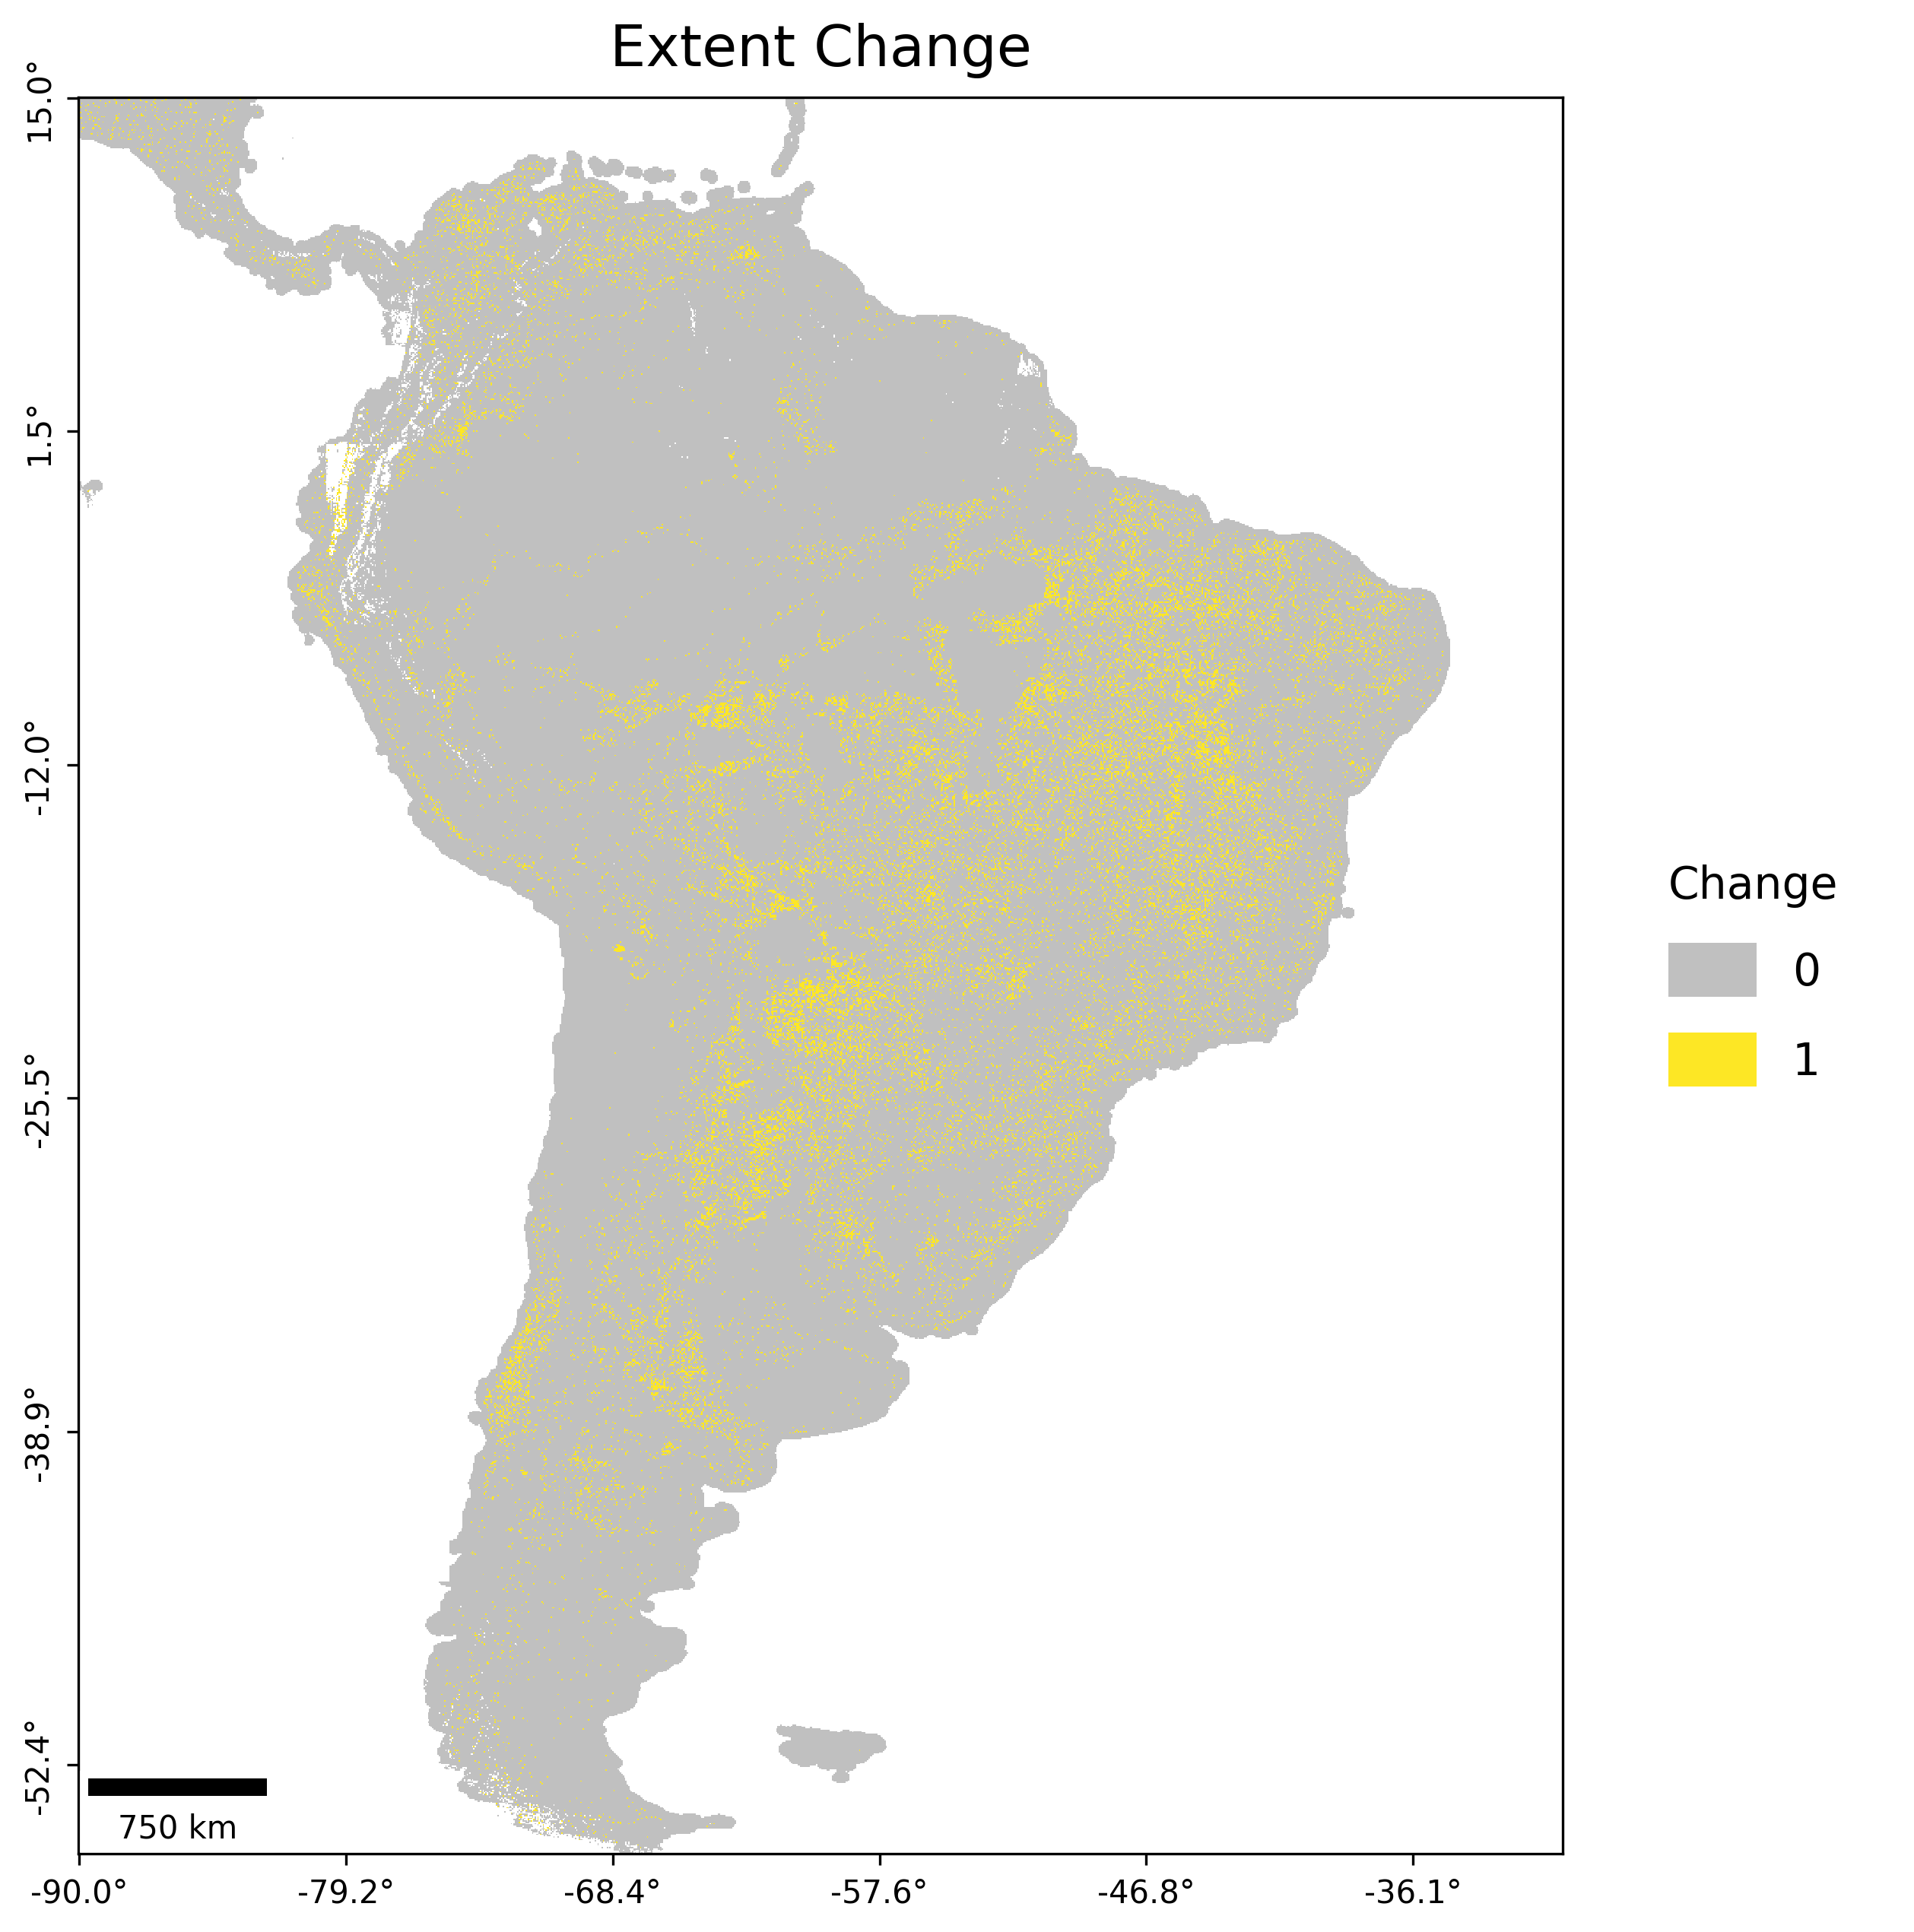

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/maps/map_extent_change.png


In [52]:
# Plot quantity component map from Drive rasters
importlib.reload(utils)

print("Generating the global Extent Change map from Drive rasters...")

raster_prefix = f"Quantity_Component_{years_to_process[0]}_{years_to_process[-1]}"

try:
    utils.plot_quantity_component_map(
        output_dir=base_drive_dir,
        nodata_val=255,
        raster_filename=raster_prefix,
        scale_factor=0.05,
    )
except Exception as e:
    print(f"\nError: {e}")

### 6.6.3 Compute Alternation Exchange raster map

In [17]:
# Submit alternation exchange raster task to GEE
importlib.reload(utils)

print("Submitting Alternation Exchange Raster Task to GEE...")

exchange_raster_task = utils.export_alternation_exchange_task_gee(
    year_list=years_to_process,
    drive_folder=folder_name,
    scale=spatial_resolution,
    nodata_val=utils.NODATA_VALUE,
)

print("\nSuccess! Task submitted to GEE.")

Submitting Alternation Exchange Raster Task to GEE...
Preparing Alternation Exchange GEE Task for 2001-2019...
Task 'Alternation_Exchange_2001_2019' submitted to Google Earth Engine with NoData: 255

Success! Task submitted to GEE.


###  6.6.4 Plot Alternation Exchange map

Generating the global Alternation Exchange map from Drive rasters...


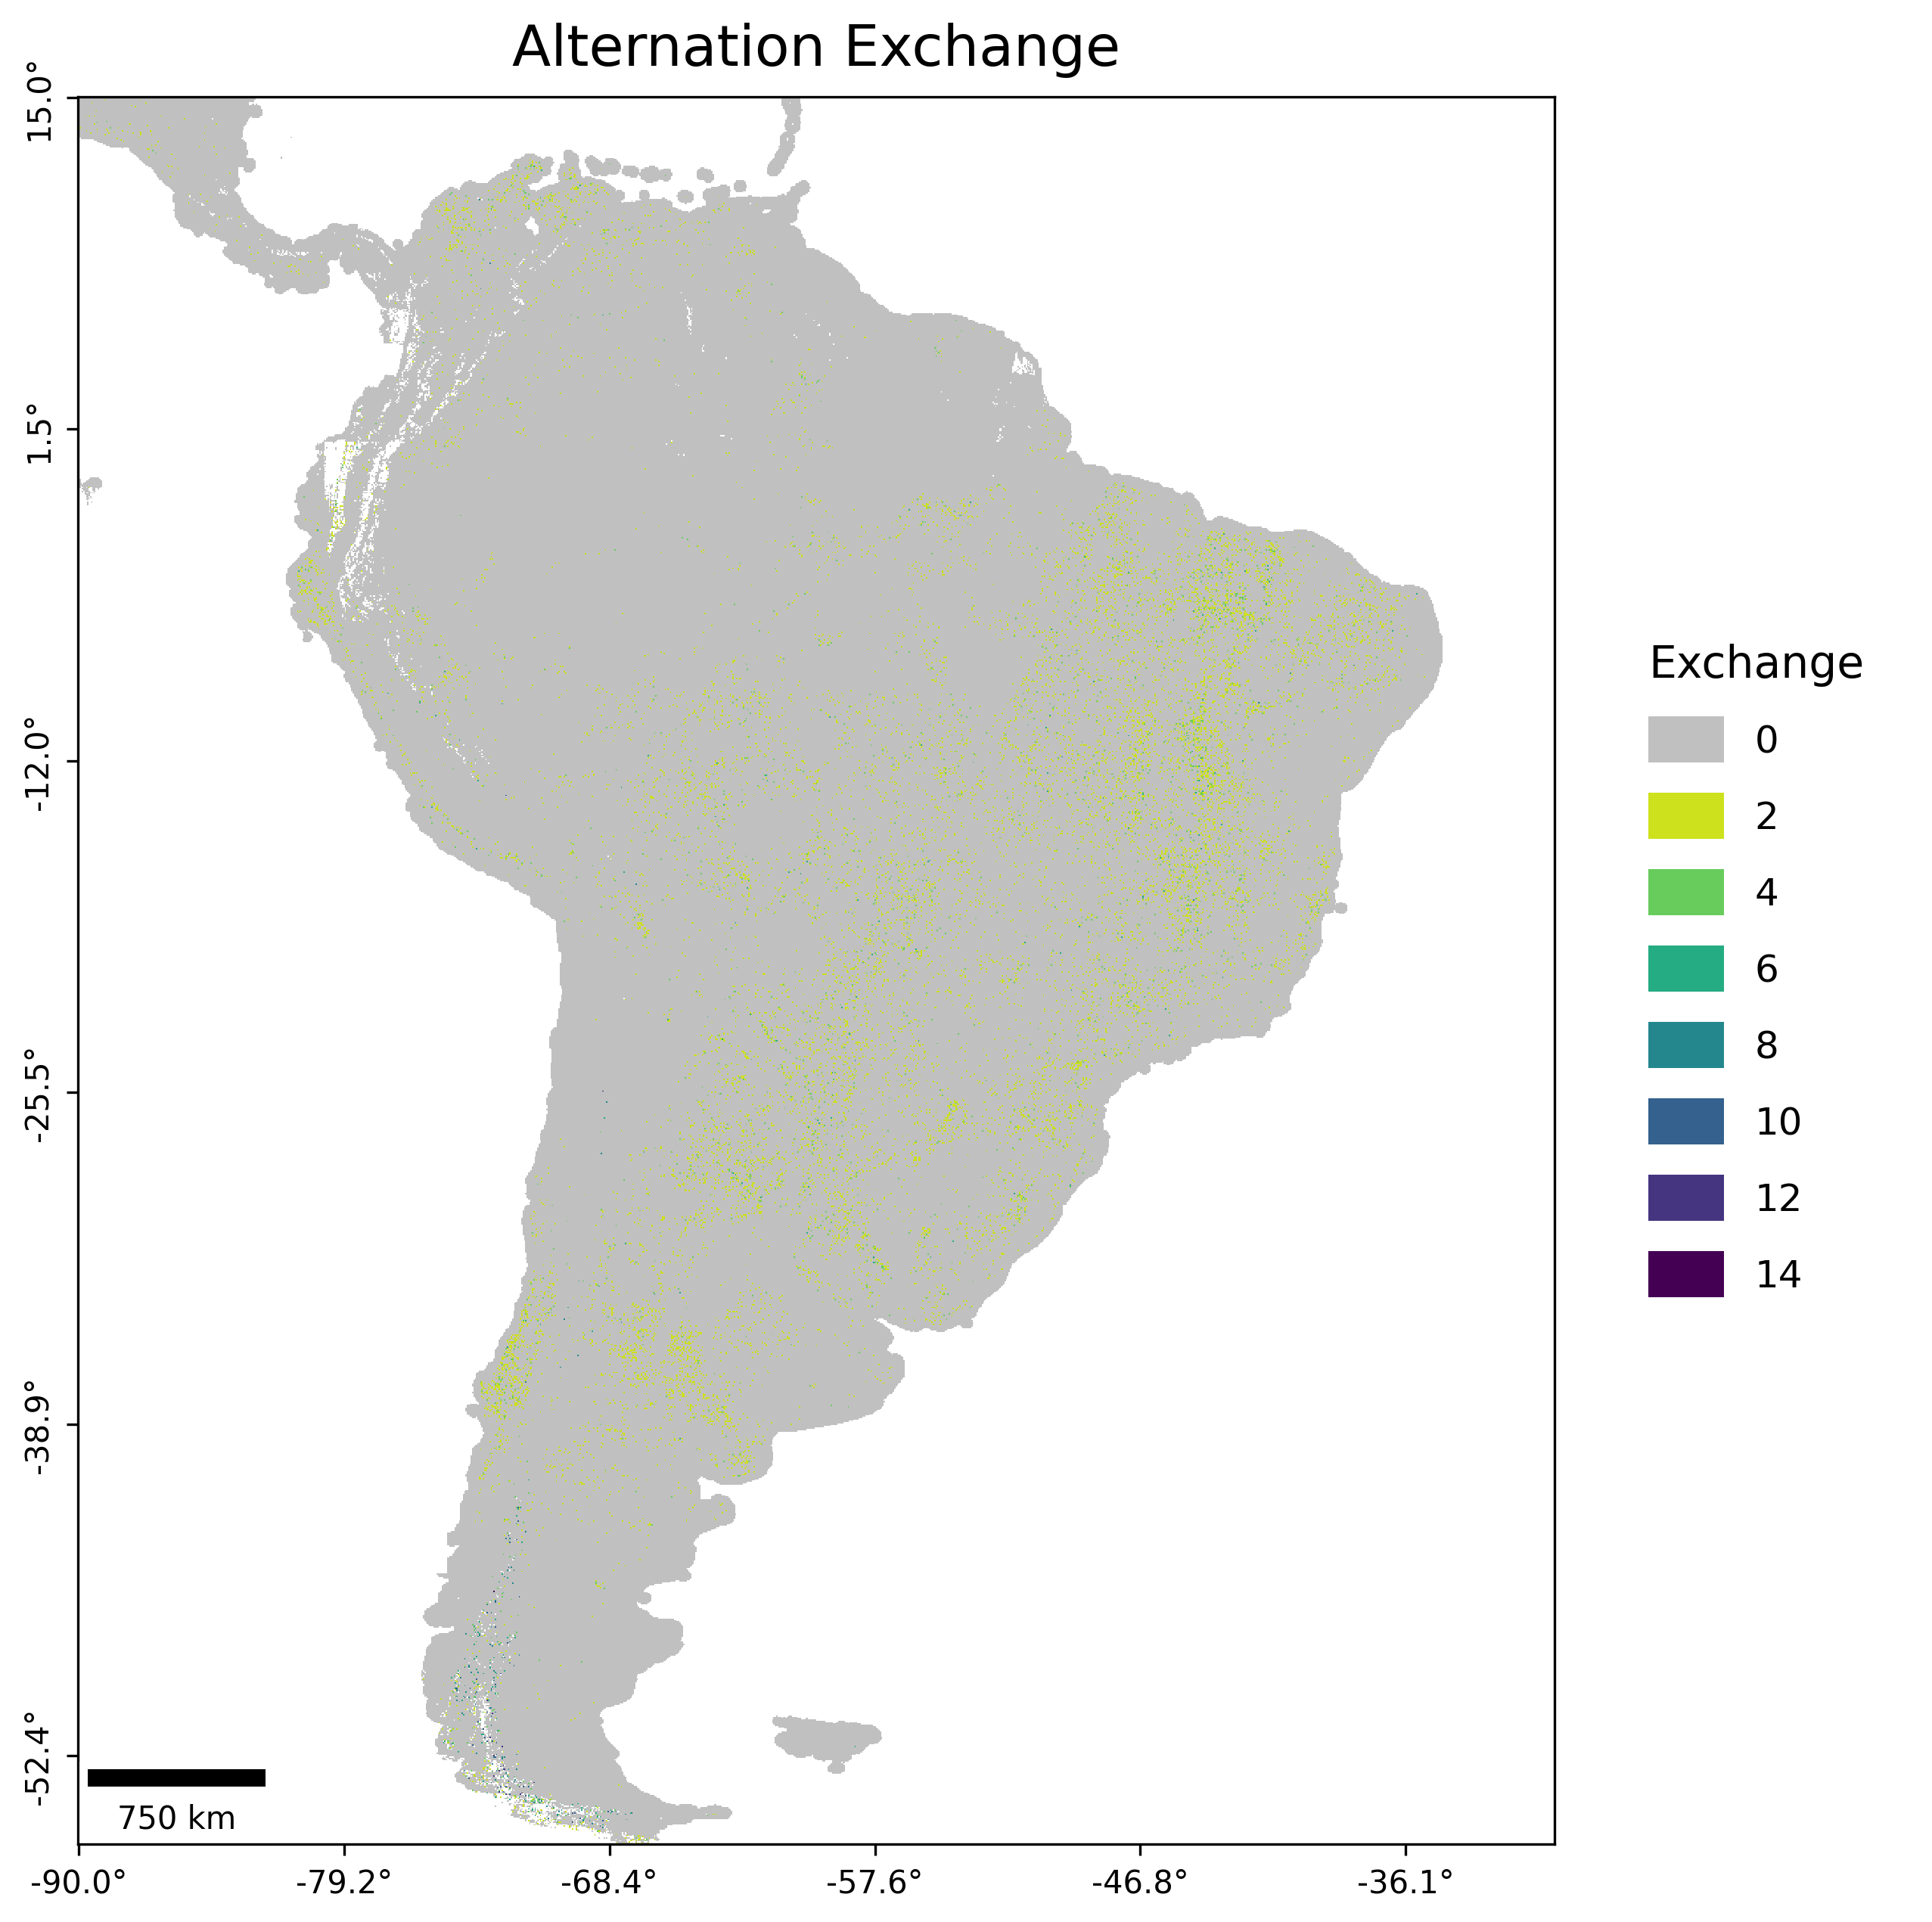

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/maps/map_alternation_exchange.png


In [54]:
# Plot alternation exchange map from Drive rasters
importlib.reload(utils)

print("Generating the global Alternation Exchange map from Drive rasters...")

raster_prefix = f"Alternation_Exchange_{years_to_process[0]}_{years_to_process[-1]}"

try:
    utils.plot_alternation_exchange_map(
        output_dir=base_drive_dir,
        nodata_val=255,
        raster_filename=raster_prefix,
        scale_factor=0.05,
    )
except Exception as e:
    print(f"\nError: {e}")

### 6.6.5 Compute Alternation Shift raster map

In [18]:
# Submit alternation shift raster task to GEE
importlib.reload(utils)

print("Submitting Alternation Shift Raster Task to GEE...")

shift_raster_task = utils.export_alternation_shift_task_gee(
    year_list=years_to_process,
    drive_folder=folder_name,
    scale=spatial_resolution,
    nodata_val=utils.NODATA_VALUE,
)

print("\nSuccess! Task submitted to GEE.")

Submitting Alternation Shift Raster Task to GEE...
Preparing Alternation Shift GEE Task for 2001-2019...
Task 'Alternation_Shift_2001_2019' submitted to Google Earth Engine with NoData: 255

Success! Task submitted to GEE.


### 6.6.6 Plot Alternation Shift map

Generating the global Alternation Shift map from Drive rasters...


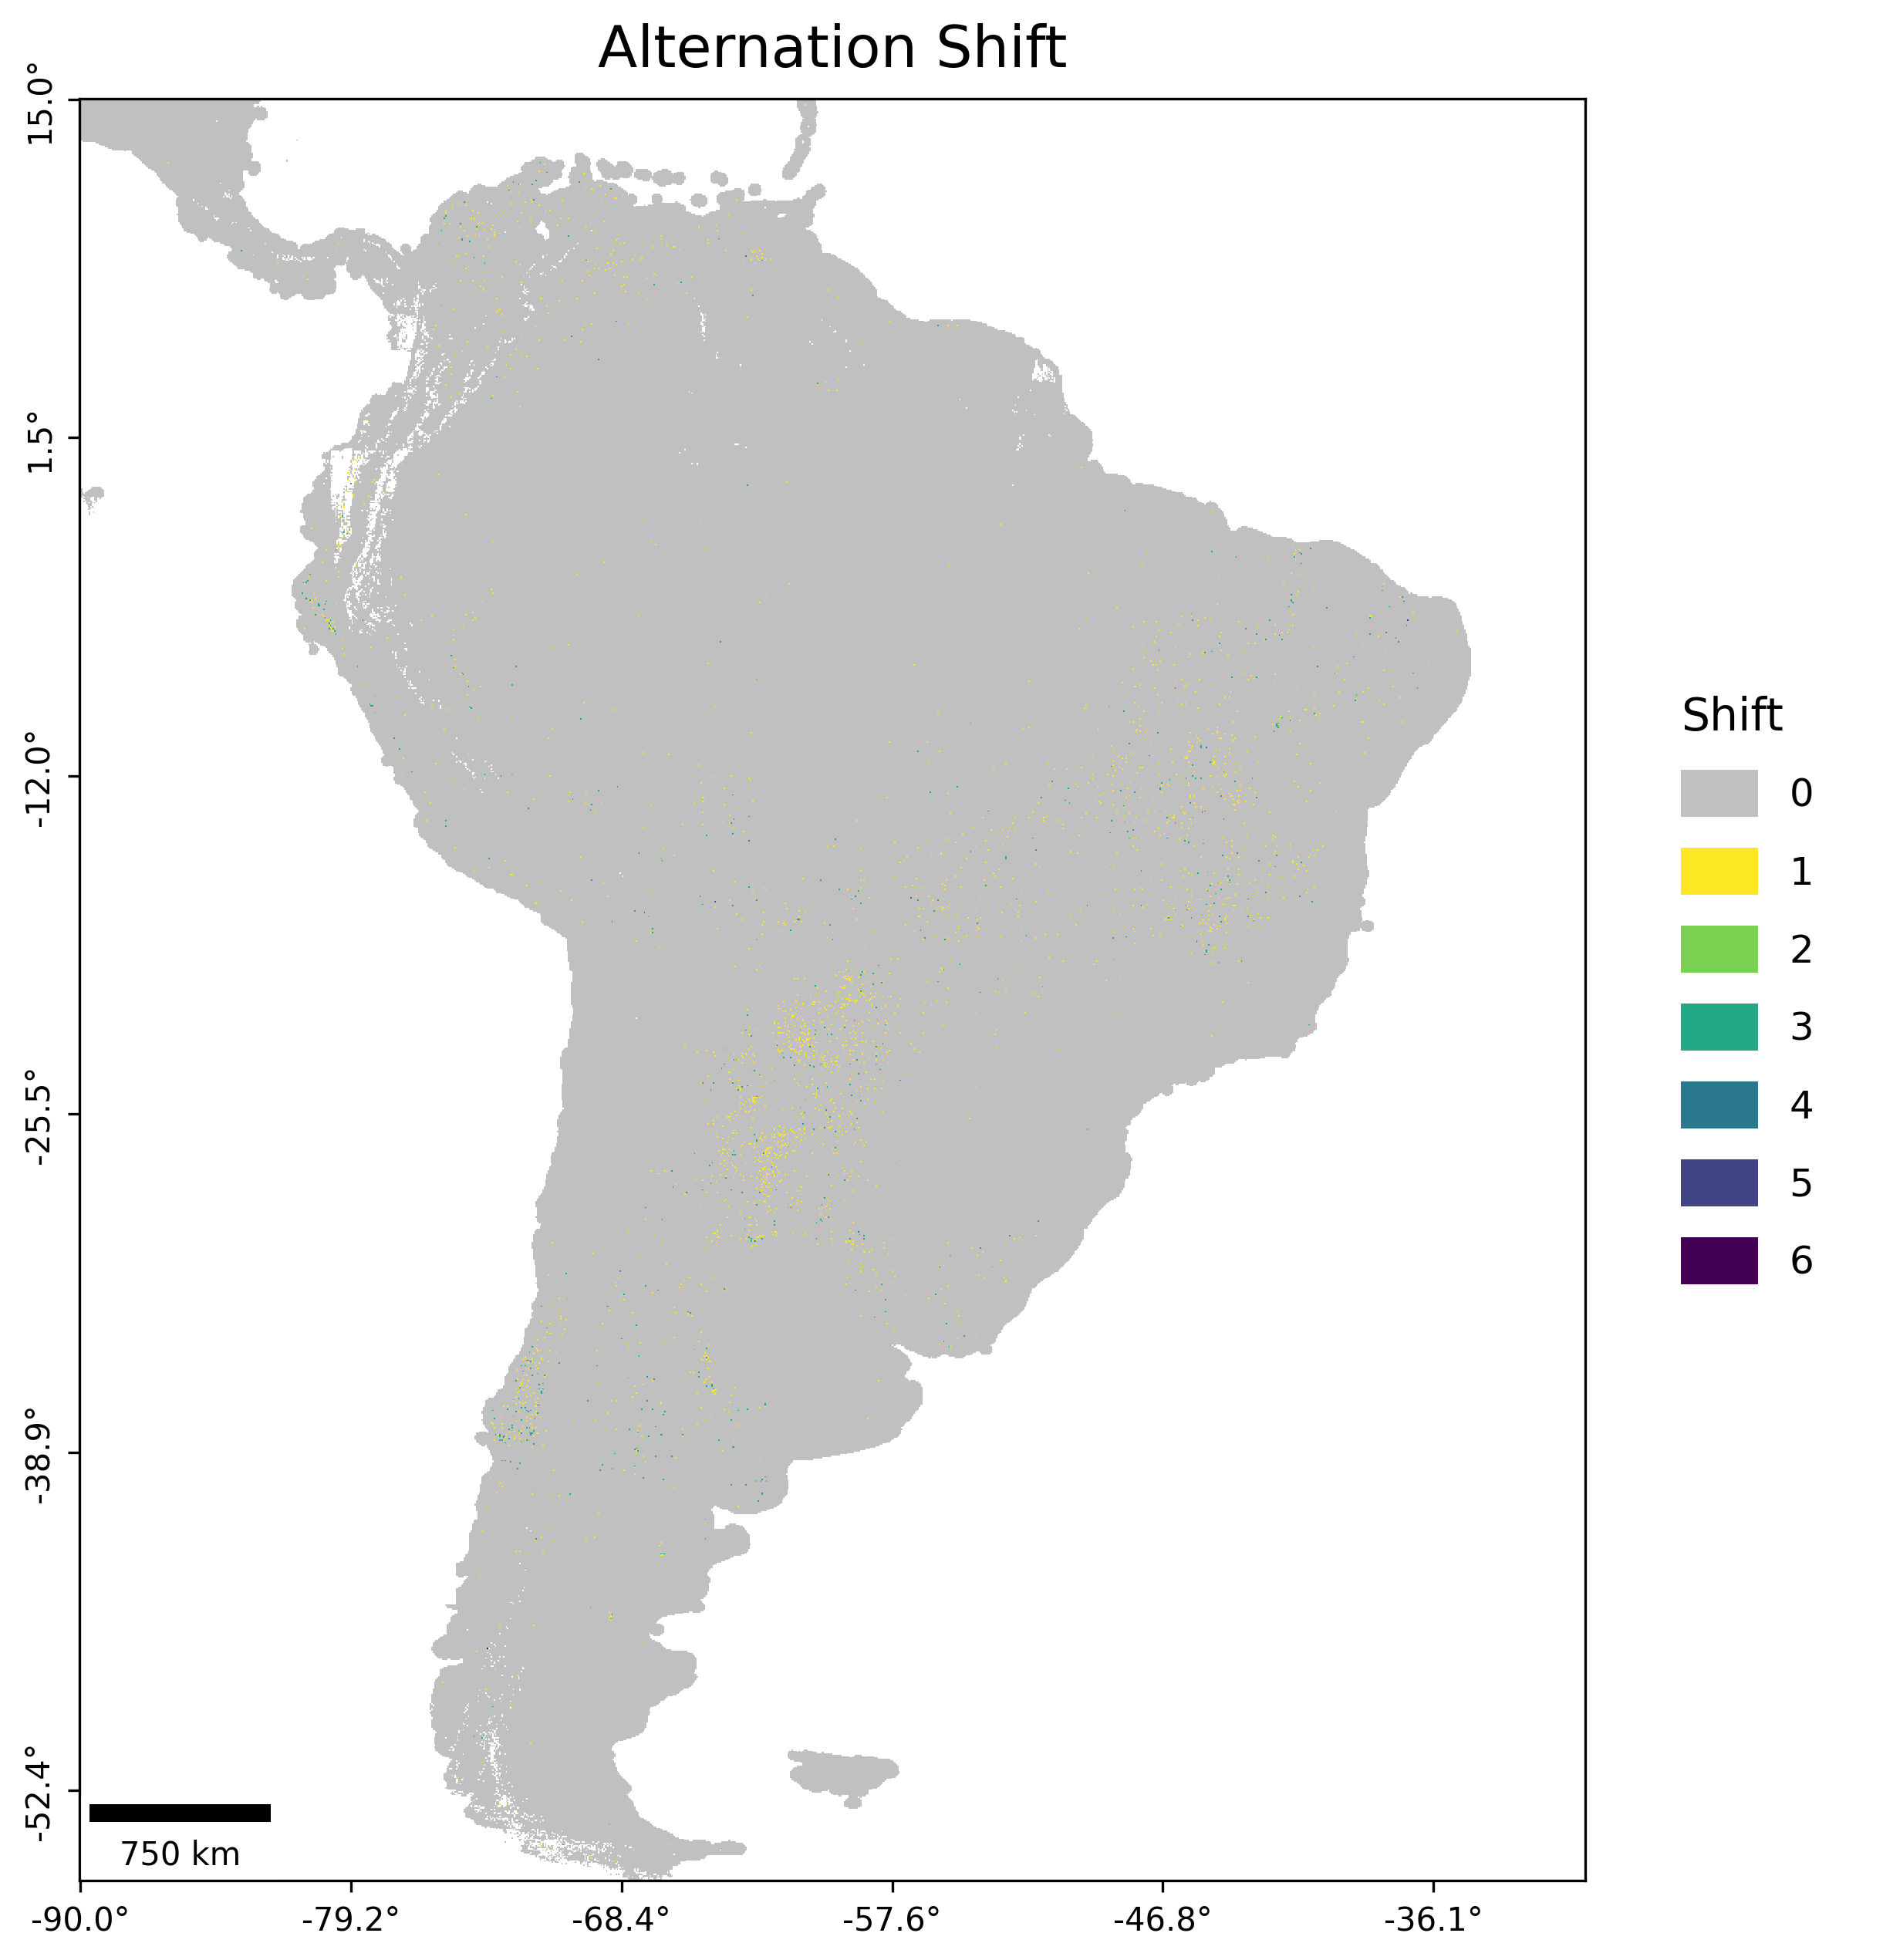

Map figure saved successfully to: /content/drive/MyDrive/GLANCE_SA_300m_2001_to_2019/maps/map_alternation_shift.png


In [55]:
# Plot alternation shift map from Drive rasters
importlib.reload(utils)

print("Generating the global Alternation Shift map from Drive rasters...")

raster_prefix = f"Alternation_Shift_{years_to_process[0]}_{years_to_process[-1]}"

try:
    utils.plot_alternation_shift_map(
        output_dir=base_drive_dir,
        nodata_val=255,
        raster_filename=raster_prefix,
        scale_factor=0.05,
    )
except Exception as e:
    print(f"\nError: {e}")